IMPORT

In [1]:
import os, random, copy
import numpy as np, pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import densenet121, DenseNet121_Weights
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

CONFIG

In [2]:
DATA_DIR = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT"

train_csv = os.path.join(DATA_DIR, "train.csv")
val_csv   = os.path.join(DATA_DIR, "validation.csv")
test_csv  = os.path.join(DATA_DIR, "test.csv")

BATCH_SIZE = 32
EPOCHS     = 30
SEED       = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print("DEVICE:", DEVICE)

DEVICE: cuda


DATASET

In [4]:
class EuroSATDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        if self.df.columns[0] == "Unnamed: 0":
            self.df = self.df.drop(columns=self.df.columns[0])
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(self.df["ClassName"].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx]["Filename"])
        label = self.class_to_idx[self.df.iloc[idx]["ClassName"]]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


TRANSFORM

In [5]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

LOAD DATA

In [6]:
train_dataset = EuroSATDataset(train_csv, DATA_DIR, train_transform)
val_dataset   = EuroSATDataset(val_csv,   DATA_DIR, val_transform)
test_dataset  = EuroSATDataset(test_csv,  DATA_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(train_dataset.classes)

In [7]:
def print_class_distribution(dataset, name):
    print(f"\n===== {name} =====")
    counts = dataset.df["ClassName"].value_counts().sort_index()
    for cls, count in counts.items():
        idx = dataset.class_to_idx[cls]
        print(f"  [{idx}] {cls}: {count} ảnh")
    print(f"  TỔNG: {len(dataset)} ảnh")

print_class_distribution(train_dataset, "TRAIN SET")
print_class_distribution(val_dataset,   "VALIDATION SET")
print_class_distribution(test_dataset,  "TEST SET")


===== TRAIN SET =====
  [0] AnnualCrop: 2100 ảnh
  [1] Forest: 2100 ảnh
  [2] HerbaceousVegetation: 2100 ảnh
  [3] Highway: 1750 ảnh
  [4] Industrial: 1750 ảnh
  [5] Pasture: 1400 ảnh
  [6] PermanentCrop: 1750 ảnh
  [7] Residential: 2100 ảnh
  [8] River: 1750 ảnh
  [9] SeaLake: 2100 ảnh
  TỔNG: 18900 ảnh

===== VALIDATION SET =====
  [0] AnnualCrop: 600 ảnh
  [1] Forest: 600 ảnh
  [2] HerbaceousVegetation: 600 ảnh
  [3] Highway: 500 ảnh
  [4] Industrial: 500 ảnh
  [5] Pasture: 400 ảnh
  [6] PermanentCrop: 500 ảnh
  [7] Residential: 600 ảnh
  [8] River: 500 ảnh
  [9] SeaLake: 600 ảnh
  TỔNG: 5400 ảnh

===== TEST SET =====
  [0] AnnualCrop: 300 ảnh
  [1] Forest: 300 ảnh
  [2] HerbaceousVegetation: 300 ảnh
  [3] Highway: 250 ảnh
  [4] Industrial: 250 ảnh
  [5] Pasture: 200 ảnh
  [6] PermanentCrop: 250 ảnh
  [7] Residential: 300 ảnh
  [8] River: 250 ảnh
  [9] SeaLake: 300 ảnh
  TỔNG: 2700 ảnh


MODEL

In [8]:
def create_model():
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.features.denseblock4.parameters():
        param.requires_grad = True

    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)

    return model.to(DEVICE)

PLOT

In [9]:
def plot_history(history, title="Training Curve"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (trung bình)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


TRAIN

In [10]:
def train_model(optimizer_name, lr):

    model = create_model()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr, momentum=0.9)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.1, patience=2)

    best_val_acc   = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    patience   = 5
    no_improve = 0

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(EPOCHS):

        # ---- TRAIN ----
        model.train()
        running_loss = 0
        train_preds, train_labels = [], []

        for images, labels in tqdm(train_loader):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(outputs, 1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_acc  = accuracy_score(train_labels, train_preds)

        # ---- VALID ----
        model.eval()
        val_preds, val_labels = [], []
        val_running_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                preds = torch.argmax(outputs, 1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(val_loader)
        val_acc  = accuracy_score(val_labels, val_preds)

        # In LR hiện tại mỗi epoch
        current_lr = optimizer.param_groups[0]['lr']

        print(f"{optimizer_name} | LR={current_lr:.2e} | Epoch {epoch+1} | "
              f"Train Loss={train_loss:.4f} | Train Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f} | Val Acc={val_acc:.4f}")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            no_improve     = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping")
                break

    model.load_state_dict(best_model_wts)

    return model, best_val_acc, history

EVALUATE

In [11]:
def evaluate_model(model):
    model.eval()
    test_preds, test_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = torch.argmax(outputs, 1).cpu().numpy()
            test_preds.extend(preds)
            test_labels.extend(labels.numpy())

    acc         = accuracy_score(test_labels, test_preds)
    precision   = precision_score(test_labels, test_preds, average='weighted')
    recall      = recall_score(test_labels, test_preds, average='weighted')
    f1_macro    = f1_score(test_labels, test_preds, average='macro')
    f1_weighted = f1_score(test_labels, test_preds, average='weighted')

    print("\n===== CLASSIFICATION REPORT =====")
    print(classification_report(test_labels, test_preds))

    print("\n===== CONFUSION MATRIX =====")
    cm = confusion_matrix(test_labels, test_preds)
    print(cm)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        "Accuracy":    acc,
        "Precision":   precision,
        "Recall":      recall,
        "F1_macro":    f1_macro,
        "F1_weighted": f1_weighted
    }

MAINLOOP

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 159MB/s]
100%|██████████| 591/591 [03:50<00:00,  2.56it/s]


Adam | LR=1.00e-03 | Epoch 1 | Train Loss=0.2442 | Train Acc=0.9187 | Val Loss=0.1422 | Val Acc=0.9524


100%|██████████| 591/591 [02:08<00:00,  4.61it/s]


Adam | LR=1.00e-03 | Epoch 2 | Train Loss=0.1419 | Train Acc=0.9499 | Val Loss=0.0826 | Val Acc=0.9717


...

Adam | LR=1.00e-06 | Epoch 26 | Train Loss=0.0300 | Train Acc=0.9903 | Val Loss=0.0630 | Val Acc=0.9811


100%|██████████| 591/591 [02:08<00:00,  4.60it/s]


Adam | LR=1.00e-07 | Epoch 27 | Train Loss=0.0319 | Train Acc=0.9895 | Val Loss=0.0614 | Val Acc=0.9809


100%|██████████| 591/591 [02:07<00:00,  4.64it/s]


Adam | LR=1.00e-07 | Epoch 28 | Train Loss=0.0319 | Train Acc=0.9889 | Val Loss=0.0649 | Val Acc=0.9806
Early stopping


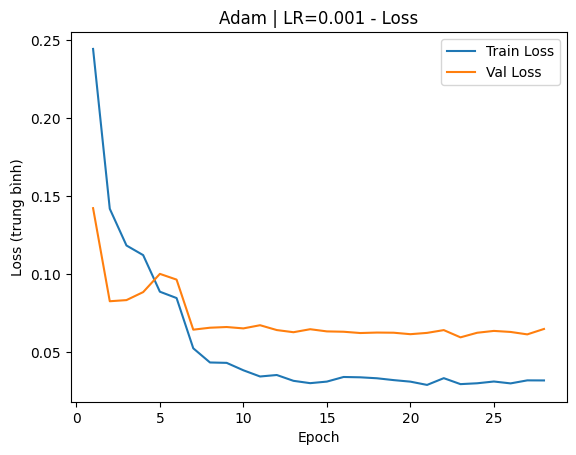

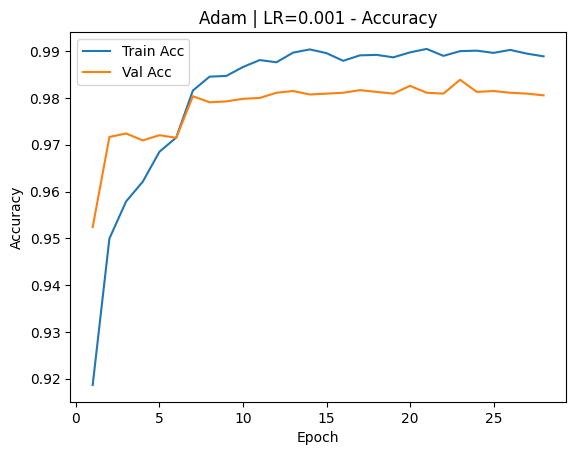

100%|██████████| 591/591 [02:08<00:00,  4.60it/s]


Adam | LR=1.00e-04 | Epoch 1 | Train Loss=0.3962 | Train Acc=0.8913 | Val Loss=0.1218 | Val Acc=0.9630


100%|██████████| 591/591 [02:08<00:00,  4.59it/s]


Adam | LR=1.00e-04 | Epoch 2 | Train Loss=0.1589 | Train Acc=0.9508 | Val Loss=0.1024 | Val Acc=0.9669


100%|██████████| 591/591 [02:08<00:00,  4.60it/s]


...

Adam | LR=1.00e-05 | Epoch 22 | Train Loss=0.0186 | Train Acc=0.9951 | Val Loss=0.0607 | Val Acc=0.9800


100%|██████████| 591/591 [02:04<00:00,  4.73it/s]


Adam | LR=1.00e-06 | Epoch 23 | Train Loss=0.0175 | Train Acc=0.9949 | Val Loss=0.0591 | Val Acc=0.9804


100%|██████████| 591/591 [02:04<00:00,  4.76it/s]


Adam | LR=1.00e-06 | Epoch 24 | Train Loss=0.0159 | Train Acc=0.9961 | Val Loss=0.0598 | Val Acc=0.9813
Early stopping


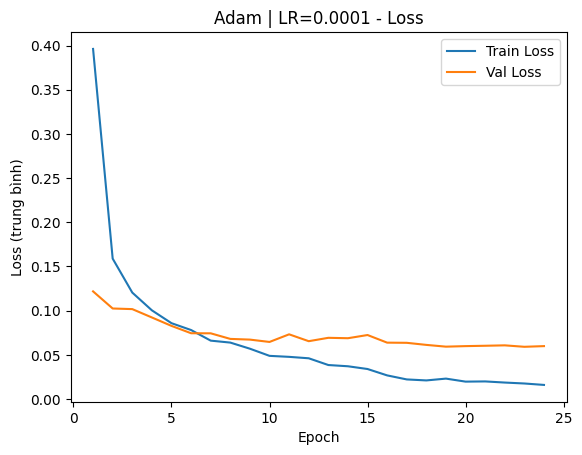

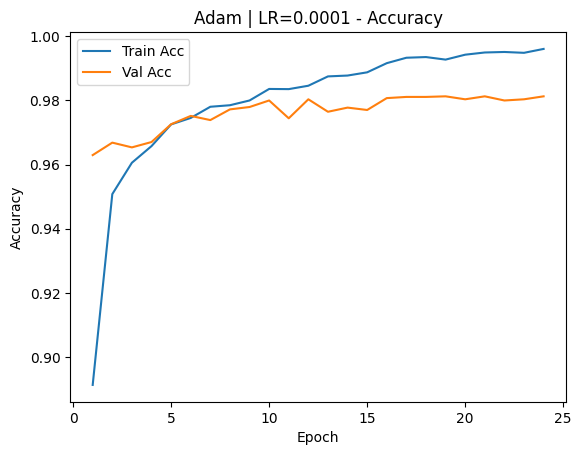

100%|██████████| 591/591 [02:05<00:00,  4.71it/s]


Adam | LR=1.00e-05 | Epoch 1 | Train Loss=1.3858 | Train Acc=0.6520 | Val Loss=0.7838 | Val Acc=0.8439


100%|██████████| 591/591 [02:06<00:00,  4.66it/s]


Adam | LR=1.00e-05 | Epoch 2 | Train Loss=0.5710 | Train Acc=0.8729 | Val Loss=0.3985 | Val Acc=0.9078


100%|██████████| 591/591 [02:08<00:00,  4.60it/s]


...

Adam | LR=1.00e-06 | Epoch 28 | Train Loss=0.0953 | Train Acc=0.9687 | Val Loss=0.0821 | Val Acc=0.9748


100%|██████████| 591/591 [02:06<00:00,  4.66it/s]


Adam | LR=1.00e-06 | Epoch 29 | Train Loss=0.0900 | Train Acc=0.9714 | Val Loss=0.0830 | Val Acc=0.9750


100%|██████████| 591/591 [02:06<00:00,  4.69it/s]


Adam | LR=1.00e-06 | Epoch 30 | Train Loss=0.0917 | Train Acc=0.9701 | Val Loss=0.0823 | Val Acc=0.9759


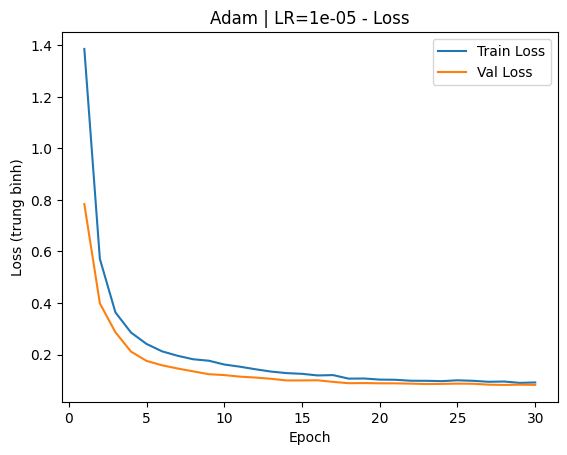

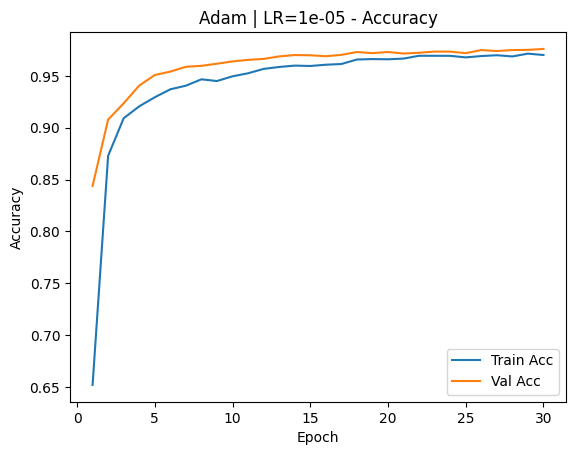


>>> BEST Adam: LR=0.001 | Val Acc=0.9839


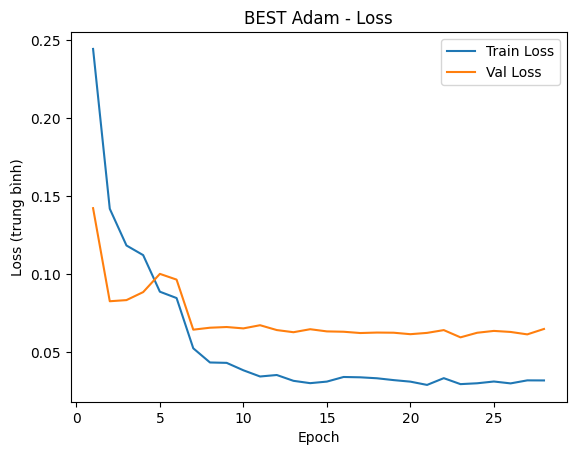

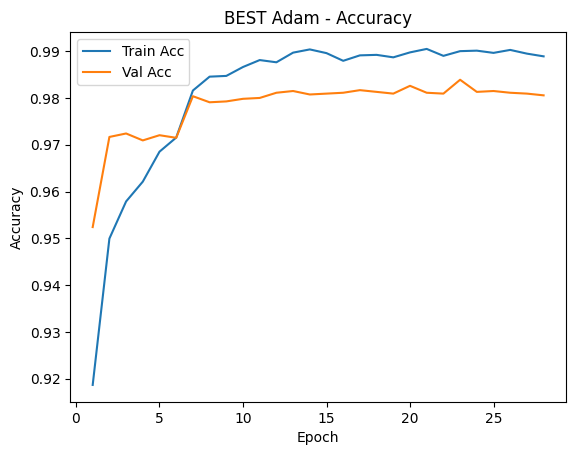


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       300
           1       1.00      1.00      1.00       300
           2       0.97      0.98      0.98       300
           3       0.99      0.98      0.99       250
           4       0.99      1.00      0.99       250
           5       0.98      0.98      0.98       200
           6       0.98      0.95      0.97       250
           7       0.99      1.00      1.00       300
           8       0.98      0.98      0.98       250
           9       1.00      1.00      1.00       300

    accuracy                           0.99      2700
   macro avg       0.99      0.99      0.99      2700
weighted avg       0.99      0.99      0.99      2700


===== CONFUSION MATRIX =====
[[295   0   0   0   0   2   3   0   0   0]
 [  0 299   0   0   0   0   0   0   1   0]
 [  0   1 295   0   0   3   0   1   0   0]
 [  1   0   0 245   0   0   0   0   4   0]
 [  

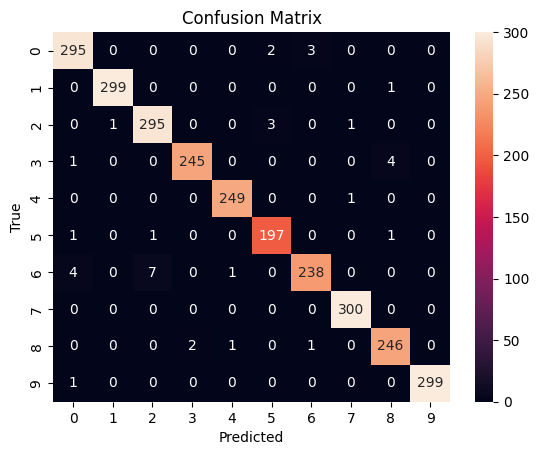

100%|██████████| 591/591 [02:07<00:00,  4.63it/s]


AdamW | LR=1.00e-03 | Epoch 1 | Train Loss=0.2451 | Train Acc=0.9188 | Val Loss=0.1513 | Val Acc=0.9496


100%|██████████| 591/591 [02:03<00:00,  4.78it/s]


AdamW | LR=1.00e-03 | Epoch 2 | Train Loss=0.1501 | Train Acc=0.9501 | Val Loss=0.1044 | Val Acc=0.9641


100%|██████████| 591/591 [02:04<00:00,  4.76it/s]


...

AdamW | LR=1.00e-05 | Epoch 24 | Train Loss=0.0196 | Train Acc=0.9929 | Val Loss=0.0559 | Val Acc=0.9817


100%|██████████| 591/591 [02:05<00:00,  4.73it/s]


AdamW | LR=1.00e-06 | Epoch 25 | Train Loss=0.0207 | Train Acc=0.9932 | Val Loss=0.0563 | Val Acc=0.9807


100%|██████████| 591/591 [02:04<00:00,  4.73it/s]


AdamW | LR=1.00e-06 | Epoch 26 | Train Loss=0.0198 | Train Acc=0.9933 | Val Loss=0.0562 | Val Acc=0.9822
Early stopping


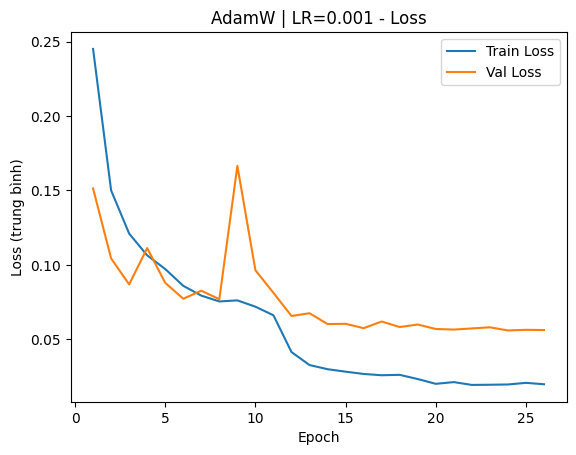

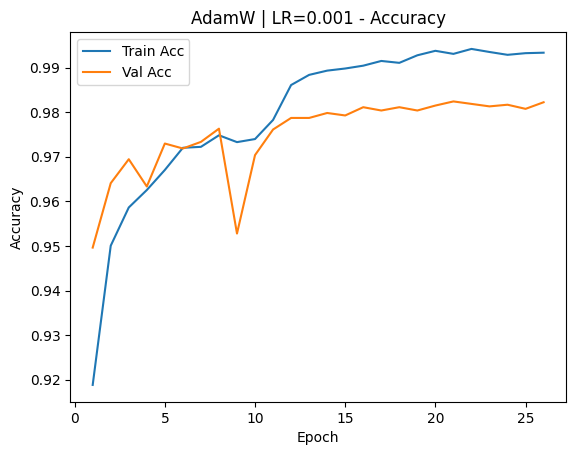

100%|██████████| 591/591 [02:11<00:00,  4.51it/s]


AdamW | LR=1.00e-04 | Epoch 1 | Train Loss=0.4011 | Train Acc=0.8884 | Val Loss=0.1352 | Val Acc=0.9578


100%|██████████| 591/591 [02:25<00:00,  4.07it/s]


AdamW | LR=1.00e-04 | Epoch 2 | Train Loss=0.1586 | Train Acc=0.9484 | Val Loss=0.1053 | Val Acc=0.9656


100%|██████████| 591/591 [02:24<00:00,  4.10it/s]


...

AdamW | LR=1.00e-05 | Epoch 21 | Train Loss=0.0220 | Train Acc=0.9934 | Val Loss=0.0603 | Val Acc=0.9813


100%|██████████| 591/591 [02:26<00:00,  4.04it/s]


AdamW | LR=1.00e-06 | Epoch 22 | Train Loss=0.0180 | Train Acc=0.9952 | Val Loss=0.0589 | Val Acc=0.9815


100%|██████████| 591/591 [02:17<00:00,  4.28it/s]


AdamW | LR=1.00e-06 | Epoch 23 | Train Loss=0.0193 | Train Acc=0.9943 | Val Loss=0.0599 | Val Acc=0.9811
Early stopping


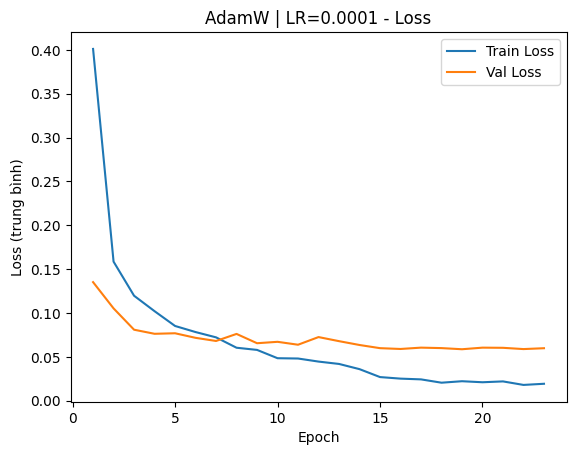

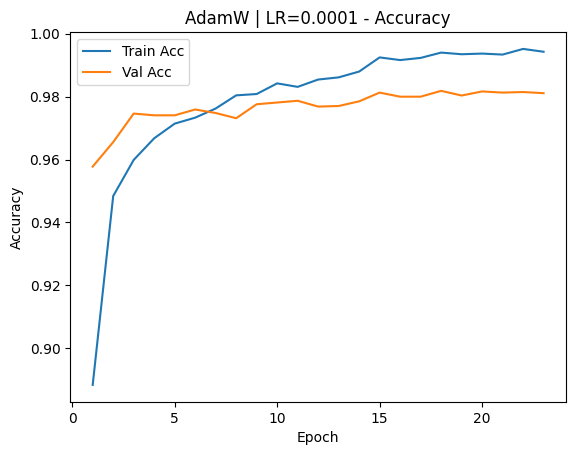

100%|██████████| 591/591 [02:34<00:00,  3.82it/s]


AdamW | LR=1.00e-05 | Epoch 1 | Train Loss=1.3932 | Train Acc=0.6496 | Val Loss=0.8424 | Val Acc=0.8411


100%|██████████| 591/591 [02:24<00:00,  4.09it/s]


AdamW | LR=1.00e-05 | Epoch 2 | Train Loss=0.5816 | Train Acc=0.8716 | Val Loss=0.4113 | Val Acc=0.9107


100%|██████████| 591/591 [02:15<00:00,  4.38it/s]


...

AdamW | LR=1.00e-05 | Epoch 28 | Train Loss=0.0790 | Train Acc=0.9753 | Val Loss=0.0760 | Val Acc=0.9739


100%|██████████| 591/591 [02:22<00:00,  4.14it/s]


AdamW | LR=1.00e-05 | Epoch 29 | Train Loss=0.0788 | Train Acc=0.9747 | Val Loss=0.0834 | Val Acc=0.9737


100%|██████████| 591/591 [02:18<00:00,  4.28it/s]


AdamW | LR=1.00e-05 | Epoch 30 | Train Loss=0.0782 | Train Acc=0.9748 | Val Loss=0.0774 | Val Acc=0.9739


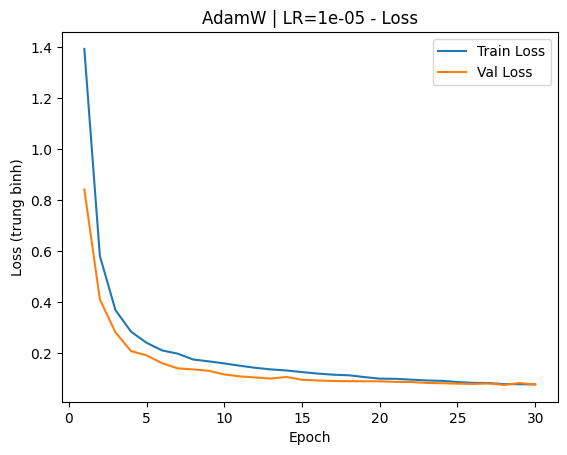

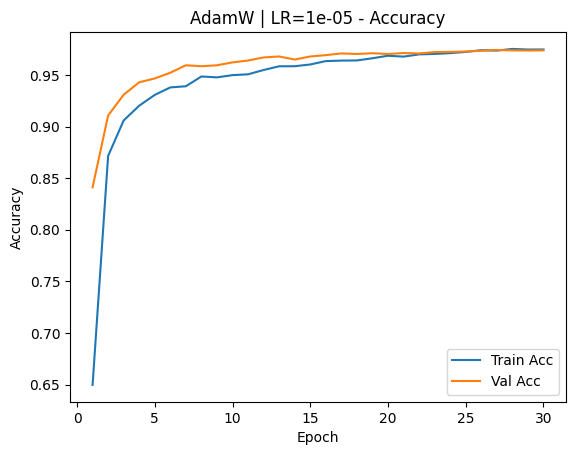


>>> BEST AdamW: LR=0.001 | Val Acc=0.9824


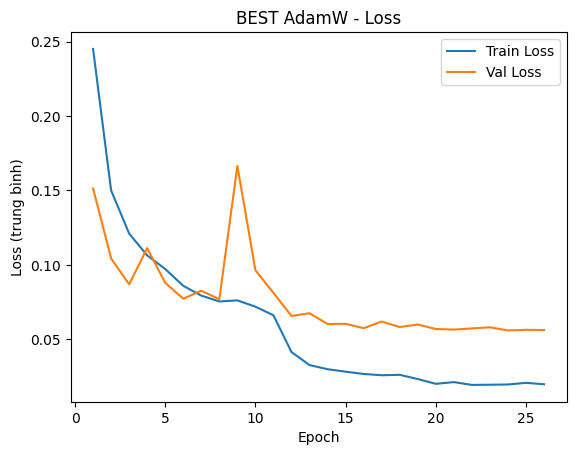

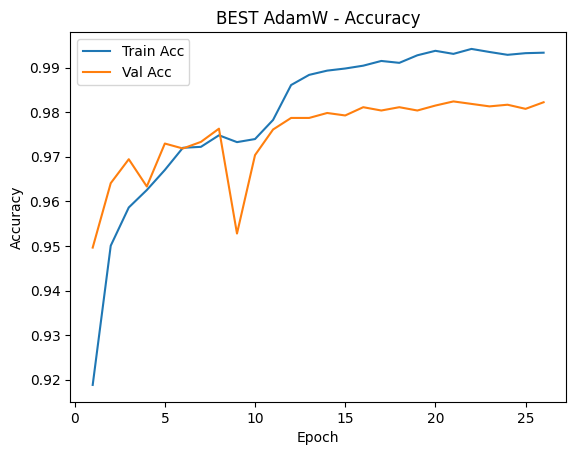


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       300
           1       1.00      0.99      0.99       300
           2       0.97      0.99      0.98       300
           3       0.98      0.96      0.97       250
           4       0.99      0.99      0.99       250
           5       0.98      0.98      0.98       200
           6       0.97      0.96      0.96       250
           7       0.99      1.00      0.99       300
           8       0.96      0.98      0.97       250
           9       1.00      0.99      0.99       300

    accuracy                           0.98      2700
   macro avg       0.98      0.98      0.98      2700
weighted avg       0.98      0.98      0.98      2700


===== CONFUSION MATRIX =====
[[292   0   0   0   0   2   5   0   1   0]
 [  0 298   0   1   0   0   0   0   1   0]
 [  0   1 296   0   0   1   1   1   0   0]
 [  0   0   0 241   2   0   0   0   7   0]
 [  

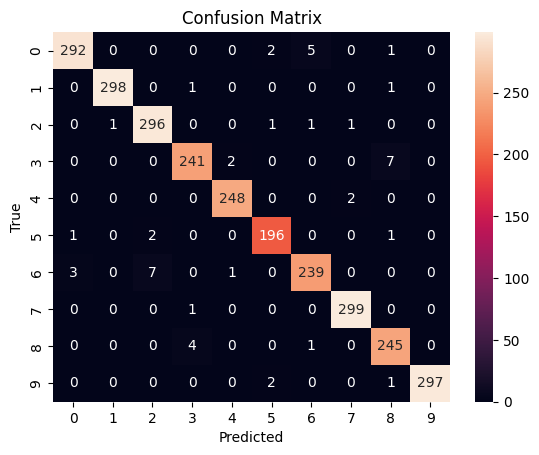

100%|██████████| 591/591 [02:15<00:00,  4.36it/s]


SGD | LR=1.00e-03 | Epoch 1 | Train Loss=0.5322 | Train Acc=0.8428 | Val Loss=0.1820 | Val Acc=0.9435


100%|██████████| 591/591 [02:12<00:00,  4.45it/s]


SGD | LR=1.00e-03 | Epoch 2 | Train Loss=0.2053 | Train Acc=0.9316 | Val Loss=0.1334 | Val Acc=0.9556


100%|██████████| 591/591 [02:19<00:00,  4.23it/s]


...

SGD | LR=1.00e-03 | Epoch 20 | Train Loss=0.0494 | Train Acc=0.9836 | Val Loss=0.0728 | Val Acc=0.9767


100%|██████████| 591/591 [02:16<00:00,  4.32it/s]


SGD | LR=1.00e-04 | Epoch 21 | Train Loss=0.0438 | Train Acc=0.9848 | Val Loss=0.0731 | Val Acc=0.9759


100%|██████████| 591/591 [02:09<00:00,  4.58it/s]


SGD | LR=1.00e-04 | Epoch 22 | Train Loss=0.0449 | Train Acc=0.9845 | Val Loss=0.0693 | Val Acc=0.9774
Early stopping


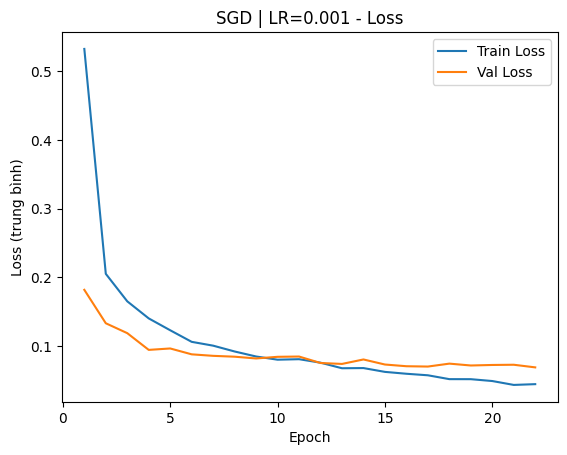

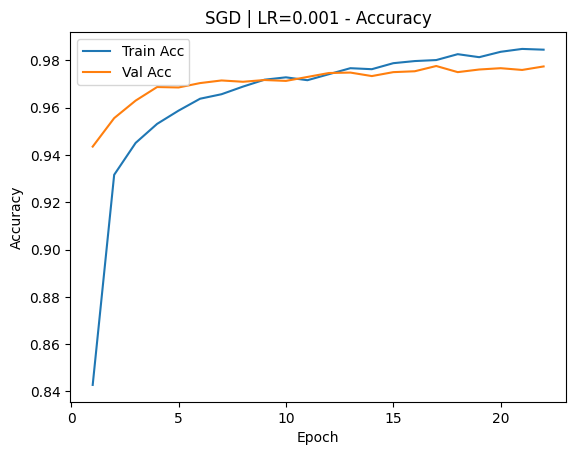

100%|██████████| 591/591 [02:09<00:00,  4.57it/s]


SGD | LR=1.00e-04 | Epoch 1 | Train Loss=1.4998 | Train Acc=0.6208 | Val Loss=0.9373 | Val Acc=0.7900


100%|██████████| 591/591 [02:07<00:00,  4.62it/s]


SGD | LR=1.00e-04 | Epoch 2 | Train Loss=0.7062 | Train Acc=0.8413 | Val Loss=0.5489 | Val Acc=0.8598


100%|██████████| 591/591 [02:08<00:00,  4.59it/s]


...

SGD | LR=1.00e-04 | Epoch 28 | Train Loss=0.1406 | Train Acc=0.9540 | Val Loss=0.1123 | Val Acc=0.9630


100%|██████████| 591/591 [02:07<00:00,  4.64it/s]


SGD | LR=1.00e-04 | Epoch 29 | Train Loss=0.1371 | Train Acc=0.9527 | Val Loss=0.1125 | Val Acc=0.9606


100%|██████████| 591/591 [02:07<00:00,  4.62it/s]


SGD | LR=1.00e-04 | Epoch 30 | Train Loss=0.1366 | Train Acc=0.9543 | Val Loss=0.1091 | Val Acc=0.9630


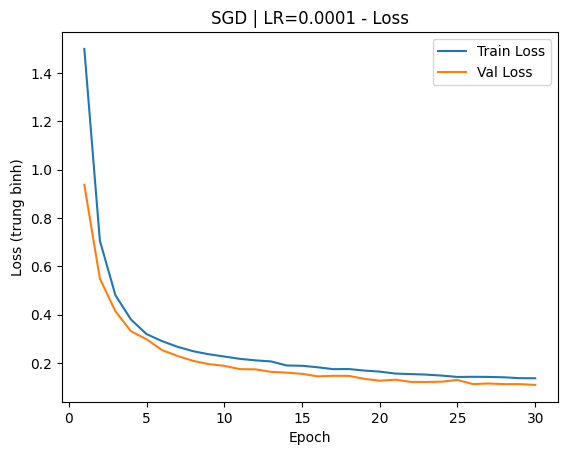

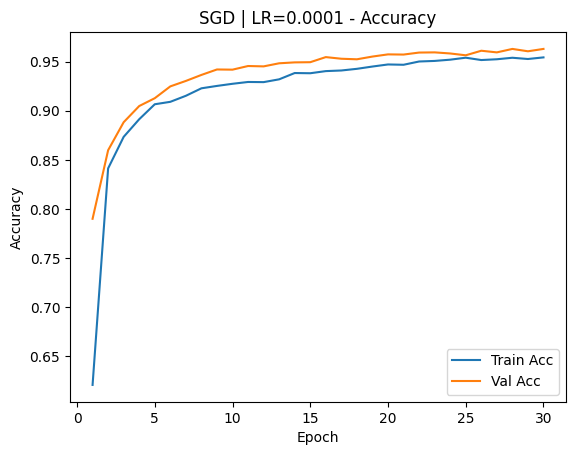

100%|██████████| 591/591 [02:09<00:00,  4.56it/s]


SGD | LR=1.00e-05 | Epoch 1 | Train Loss=2.2394 | Train Acc=0.2121 | Val Loss=2.1085 | Val Acc=0.3128


100%|██████████| 591/591 [02:11<00:00,  4.49it/s]


SGD | LR=1.00e-05 | Epoch 2 | Train Loss=1.9938 | Train Acc=0.4391 | Val Loss=1.9021 | Val Acc=0.4665


100%|██████████| 591/591 [02:09<00:00,  4.55it/s]


...

SGD | LR=1.00e-05 | Epoch 28 | Train Loss=0.4443 | Train Acc=0.8812 | Val Loss=0.4566 | Val Acc=0.8709


100%|██████████| 591/591 [02:08<00:00,  4.62it/s]


SGD | LR=1.00e-06 | Epoch 29 | Train Loss=0.4391 | Train Acc=0.8837 | Val Loss=0.4214 | Val Acc=0.8837


100%|██████████| 591/591 [02:08<00:00,  4.61it/s]


SGD | LR=1.00e-06 | Epoch 30 | Train Loss=0.4371 | Train Acc=0.8817 | Val Loss=0.4247 | Val Acc=0.8841


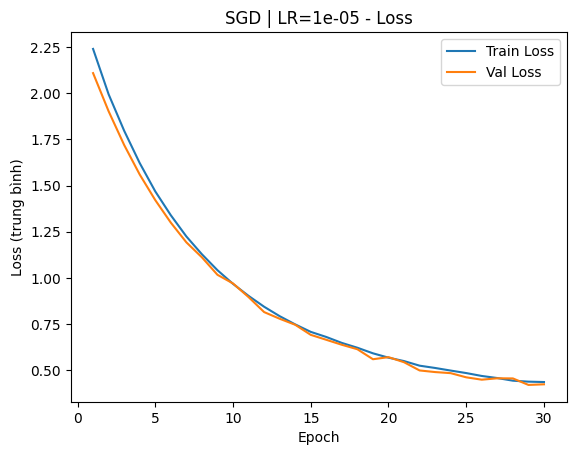

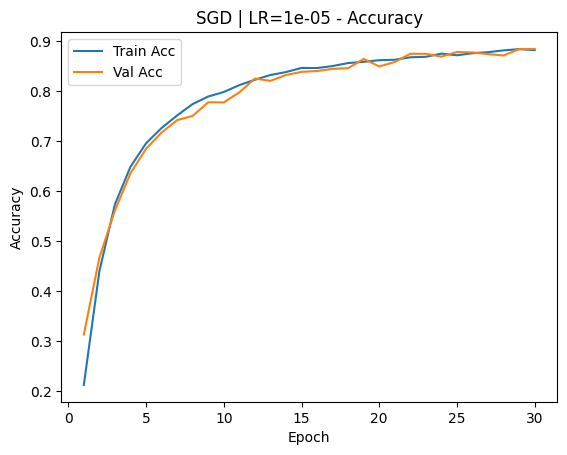


>>> BEST SGD: LR=0.001 | Val Acc=0.9776


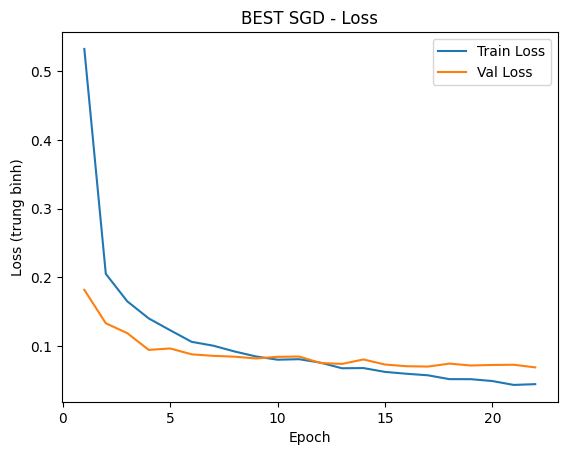

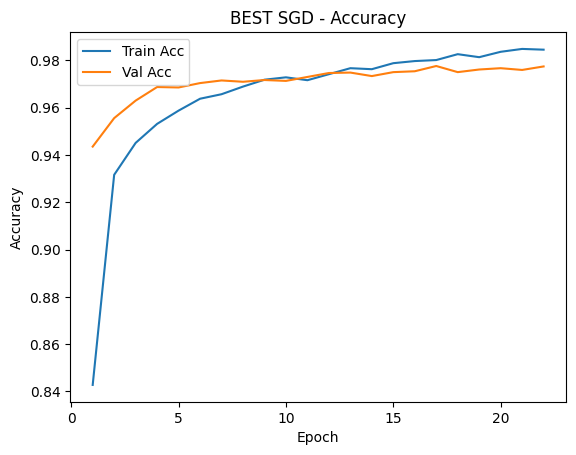


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       300
           1       0.99      0.99      0.99       300
           2       0.97      0.98      0.98       300
           3       0.98      0.94      0.96       250
           4       0.97      1.00      0.98       250
           5       0.98      0.98      0.98       200
           6       0.98      0.94      0.96       250
           7       1.00      1.00      1.00       300
           8       0.96      0.97      0.96       250
           9       1.00      1.00      1.00       300

    accuracy                           0.98      2700
   macro avg       0.98      0.98      0.98      2700
weighted avg       0.98      0.98      0.98      2700


===== CONFUSION MATRIX =====
[[294   0   0   1   0   1   3   0   1   0]
 [  0 298   0   0   0   0   0   0   2   0]
 [  0   1 295   1   0   2   1   0   0   0]
 [  0   0   0 236   4   2   0   0   8   0]
 [  

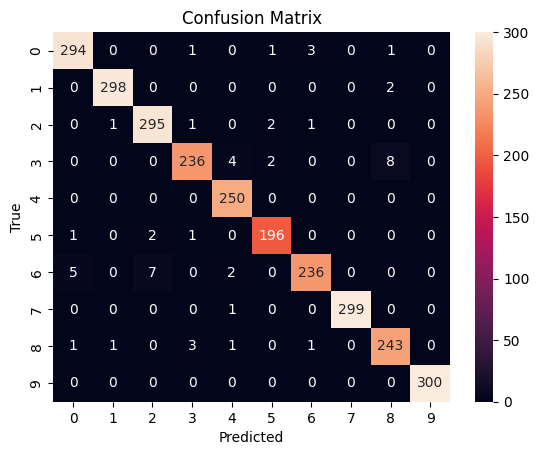

In [12]:
optimizers     = ["Adam", "AdamW", "SGD"]
learning_rates = [1e-3, 1e-4, 1e-5]

results = []

global_best_acc           = 0
global_best_model_weights = None
global_best_opt           = None
global_best_lr            = None

for opt in optimizers:

    best_acc     = 0
    best_model   = None
    best_lr      = None
    best_history = None

    for lr in learning_rates:

        model, val_acc, history = train_model(opt, lr)

        plot_history(history, title=f"{opt} | LR={lr}")

        if val_acc > best_acc:
            best_acc     = val_acc
            best_model   = model
            best_lr      = lr
            best_history = history

        if val_acc > global_best_acc:
            global_best_acc           = val_acc
            global_best_model_weights = copy.deepcopy(model.state_dict())
            global_best_opt           = opt
            global_best_lr            = lr

    print(f"\n>>> BEST {opt}: LR={best_lr} | Val Acc={best_acc:.4f}")

    plot_history(best_history, title=f"BEST {opt}")

    metrics = evaluate_model(best_model)
    metrics["Optimizer"] = opt
    metrics["Best_LR"]   = best_lr

    results.append(metrics)

COMPARISON

In [13]:
df_results = pd.DataFrame(results)

print("\n===== FINAL COMPARISON =====")
print(df_results)

best_row = df_results[
    (df_results['Optimizer'] == global_best_opt) &
    (df_results['Best_LR']   == global_best_lr)
].iloc[0]

best_test_acc = best_row['Accuracy']

print("-" * 30)
print("Best model:")
print(f"  Optimizer:           {global_best_opt}")
print(f"  Learning Rate:       {global_best_lr}")
print(f"  Validation Accuracy: {global_best_acc:.4f}")
print(f"  Test Accuracy:       {best_test_acc:.4f}")


===== FINAL COMPARISON =====
   Accuracy  Precision    Recall  F1_macro  F1_weighted Optimizer  Best_LR
0  0.986296   0.986329  0.986296  0.985777     0.986276      Adam    0.001
1  0.981852   0.981933  0.981852  0.981118     0.981853     AdamW    0.001
2  0.980370   0.980445  0.980370  0.979360     0.980320       SGD    0.001
------------------------------
Best model:
  Optimizer:           Adam
  Learning Rate:       0.001
  Validation Accuracy: 0.9839
  Test Accuracy:       0.9863


SAVE CHECK POINT

In [14]:
save_path = '/kaggle/working/DenseNet121_EuroSAT_Best.pth'

torch.save({
    "model_state_dict": global_best_model_weights,
    "optimizer":        global_best_opt,
    "lr":               global_best_lr,
    "val_acc":          global_best_acc,
    "classes":          train_dataset.classes,
    "class_to_idx":     train_dataset.class_to_idx,
}, save_path)

print(f"\nModel đã được lưu tại: {save_path}")


Model đã được lưu tại: /kaggle/working/DenseNet121_EuroSAT_Best.pth
